In [1]:
import duckdb
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv(r"c:\Users\baavi\Downloads\Cleaned_yellow_tripdata_2025-01.csv")

In [3]:
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,PULocationID,DOLocationID,payment_type,fare_amount,extra,...,total_amount,cbd_congestion_fee,trip_duration_min,pickup_hour,pickup_day,pickup_weekday,is_weekend,revenue_per_mile,revenue_per_minute,tip_percentage
0,1,2026-01-18 12:35:13,2026-01-18 12:46:05,1.0,3.90,68,238,1,17.00,3.25,...,24.25,0.75,10.87,12,18,6,1,6.22,2.23,0.15
1,2,2026-01-28 01:01:57,2026-01-28 01:34:45,1.0,13.95,69,61,0,49.13,0.00,...,58.09,0.00,32.80,1,28,2,0,4.16,1.77,0.00
2,2,2026-01-09 10:35:27,2026-01-09 11:05:50,1.0,13.79,13,138,1,55.50,5.00,...,84.82,0.75,30.38,10,9,4,0,6.15,2.79,0.35
3,2,2026-01-24 22:26:51,2026-01-24 22:37:03,1.0,1.76,164,79,2,11.40,1.00,...,17.15,0.75,10.20,22,24,5,1,9.74,1.68,0.00
4,2,2026-01-01 01:59:23,2026-01-01 02:13:41,1.0,7.42,74,232,0,41.06,0.00,...,45.81,0.75,14.30,1,1,3,0,6.17,3.20,0.00


In [4]:
df.tail()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,PULocationID,DOLocationID,payment_type,fare_amount,extra,...,total_amount,cbd_congestion_fee,trip_duration_min,pickup_hour,pickup_day,pickup_weekday,is_weekend,revenue_per_mile,revenue_per_minute,tip_percentage
1367283,2,2026-01-13 12:52:28,2026-01-13 12:57:52,1.0,0.66,164,233,0,11.62,0.0,...,16.37,0.75,5.40,12,13,1,0,24.80,3.03,0.00
1367284,2,2026-01-06 05:24:06,2026-01-06 05:43:32,1.0,3.73,68,145,0,20.27,0.0,...,31.96,0.75,19.43,5,6,1,0,8.57,1.64,0.00
1367285,1,2026-01-19 14:48:36,2026-01-19 15:09:35,1.0,3.00,162,45,0,22.35,0.0,...,40.58,0.75,20.98,14,19,0,0,13.53,1.93,0.26
1367286,1,2026-01-11 05:57:10,2026-01-11 06:02:47,1.0,1.20,236,238,1,7.90,3.5,...,16.75,0.00,5.62,5,11,6,1,13.96,2.98,0.49
1367287,2,2026-01-21 20:28:26,2026-01-21 20:41:07,1.0,2.11,262,238,0,15.93,0.0,...,22.93,0.00,12.68,20,21,2,0,10.87,1.81,0.00


In [5]:
df.isnull().sum()

VendorID                 0
tpep_pickup_datetime     0
tpep_dropoff_datetime    0
passenger_count          0
trip_distance            0
PULocationID             0
DOLocationID             0
payment_type             0
fare_amount              0
extra                    0
mta_tax                  0
tip_amount               0
tolls_amount             0
improvement_surcharge    0
total_amount             0
cbd_congestion_fee       0
trip_duration_min        0
pickup_hour              0
pickup_day               0
pickup_weekday           0
is_weekend               0
revenue_per_mile         0
revenue_per_minute       0
tip_percentage           0
dtype: int64

In [6]:
#lets establish connection for sql
connection=duckdb.connect()
connection.register("taxi",df)

In [7]:
#Hourly Demand Analysis using SQL

query = """
select 
  pickup_hour,
  count(*) as total_trips,
  round(sum(total_amount), 2) as total_revenue,
  round(avg(fare_amount), 2) as avg_fare,
  round(avg(tip_amount), 2) as avg_tip,
  round(avg(trip_duration_min), 2) as avg_trip_duration
from taxi
group by pickup_hour
order by pickup_hour
"""
hourly_df=connection.execute(query).df()
hourly_df.head()

,pickup_hour,total_trips,total_revenue,avg_fare,avg_tip,avg_trip_duration
0,0,42650,1246960.81,21.18,2.05,14.89
1,1,29388,831764.89,20.76,1.73,14.08
2,2,20706,561816.60,19.82,1.60,13.77
3,3,14766,403628.56,20.28,1.45,14.07
4,4,10656,321120.56,22.94,1.53,15.56


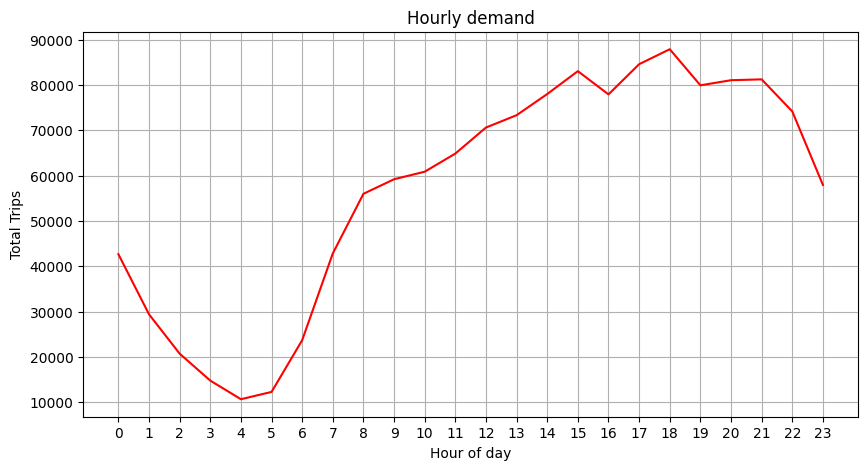

In [8]:
#Trips by Hour
plt.figure(figsize=(10,5))
sns.lineplot(x="pickup_hour",y="total_trips",data=hourly_df,color="red")
plt.title("Hourly demand")
plt.xlabel("Hour of day")
plt.ylabel("Total Trips")
plt.xticks(range(0,24))
plt.grid(True)
plt.show()

In [9]:
print("Highest value for the trips:",hourly_df['total_trips'].max())
print("middle value for the trips:",hourly_df['total_trips'].median())
print("low value for the trips:",hourly_df['total_trips'].min())

Highest value for the trips: 87871
middle value for the trips: 62848.5
low value for the trips: 10656


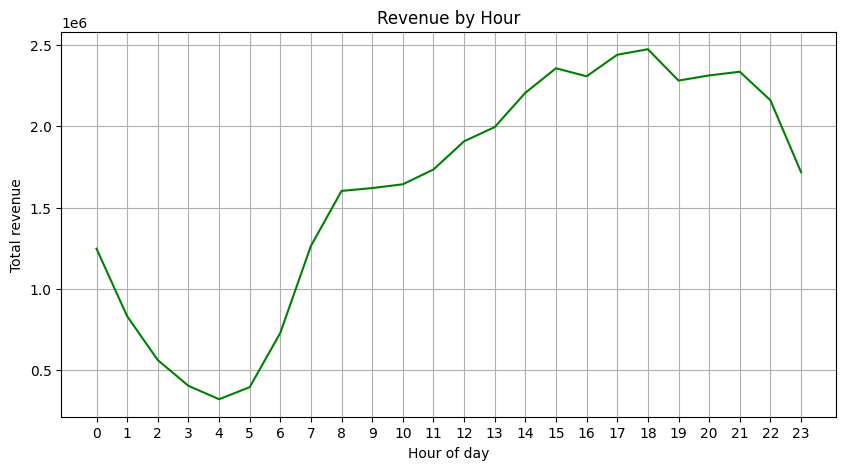

In [10]:
#PEAK DEAMND OCCURS AT 93,714 AT 6PM
#lOWEST DEMAND IS OBSERVED AT 4AM 

plt.figure(figsize=(10,5))
sns.lineplot(x="pickup_hour",y="total_revenue",data=hourly_df,color="green")
plt.title("Revenue by Hour")
plt.xlabel("Hour of day")
plt.ylabel("Total revenue")
plt.xticks(range(0,24))
plt.grid(True)
plt.show()

In [11]:
print("highest value for total revenue :",hourly_df["total_revenue"].max())
print("middle value for total revenue :", hourly_df["total_revenue"].median())
print("lowest value for total revenue :", hourly_df["total_revenue"].min())

highest value for total revenue : 2473721.1
middle value for total revenue : 1725641.99
lowest value for total revenue : 321120.56


In [12]:
#AVERAGE REVENUE PER TRIP
hourly_df['Revenue_per_trip']=hourly_df['total_revenue']/hourly_df['total_trips']

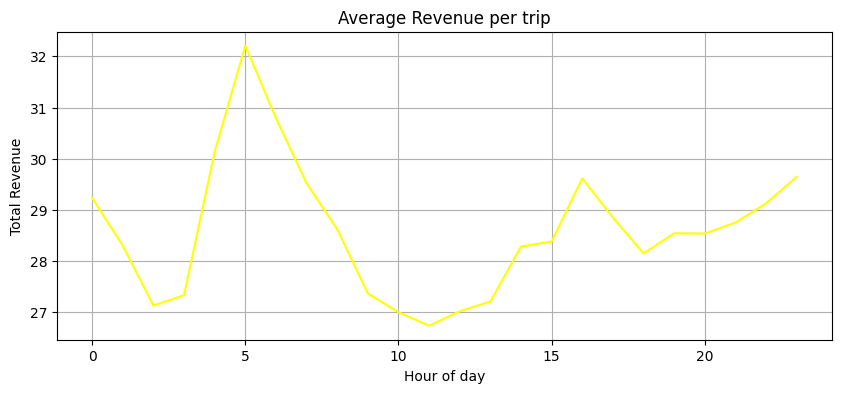

In [13]:
plt.figure(figsize=(10,4))
sns.lineplot(data=hourly_df,x="pickup_hour",y='Revenue_per_trip',color="yellow")
plt.title("Average Revenue per trip")
plt.xlabel("Hour of day")
plt.ylabel("Total Revenue")
plt.grid(True)
plt.show()

In [14]:
#HIGHEST REVENUE TRIP OCCURS AT 5TH HOUR
#lowest revenue trip occurs at 2nd hour

In [15]:
query = """
select 
    is_weekend,
    count(*) as total_trips,
    sum(total_amount) as total_revenue,
    round(avg(fare_amount), 2) as avg_fare,
    round(avg(trip_distance), 2) as avg_distance,
    round(avg(trip_duration_min), 2) as avg_duration,
    round(avg(tip_percentage), 2) as avg_tip_percentage,
    (case when is_weekend = 0 then 'Weekday' else 'Weekend' end) as day_type
from taxi
group by is_weekend
"""

weekend_df=connection.execute(query).df()
weekend_df.head()

,is_weekend,total_trips,total_revenue,avg_fare,avg_distance,avg_duration,avg_tip_percentage,day_type
0,1,396917,1.073486e+07,19.35,3.28,15.45,0.14,Weekend
1,0,970371,2.810952e+07,20.29,3.28,17.69,0.17,Weekday


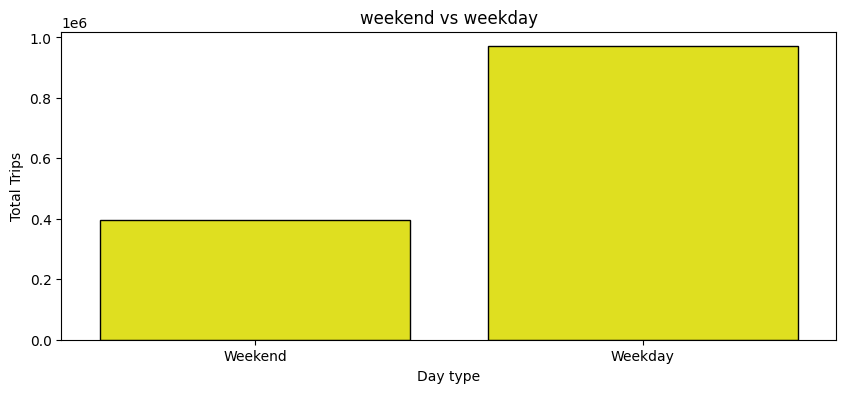

In [16]:
plt.figure(figsize=(10,4))
sns.barplot(x="day_type",y="total_trips",data=weekend_df,color="yellow",edgecolor="black")
plt.title("weekend vs weekday")
plt.xlabel("Day type")
plt.ylabel("Total Trips")
plt.show()

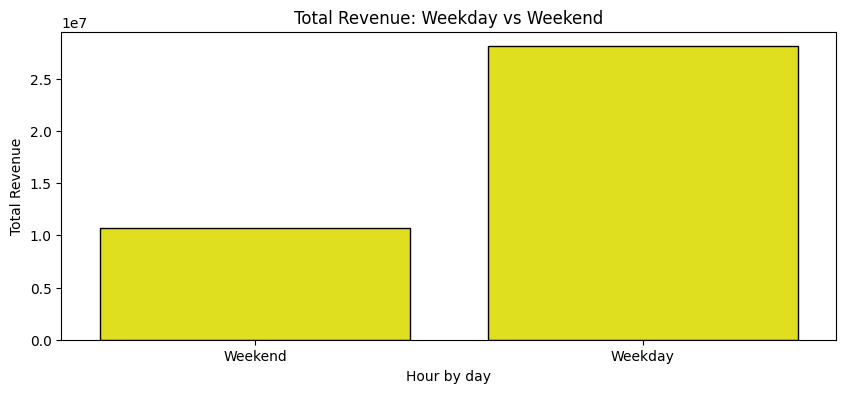

In [17]:
plt.figure(figsize=(10,4))
sns.barplot(x="day_type",y="total_revenue",data=weekend_df,color="yellow",edgecolor="black")
plt.title("Total Revenue: Weekday vs Weekend")
plt.xlabel("Hour by day")
plt.ylabel("Total Revenue")
plt.show()

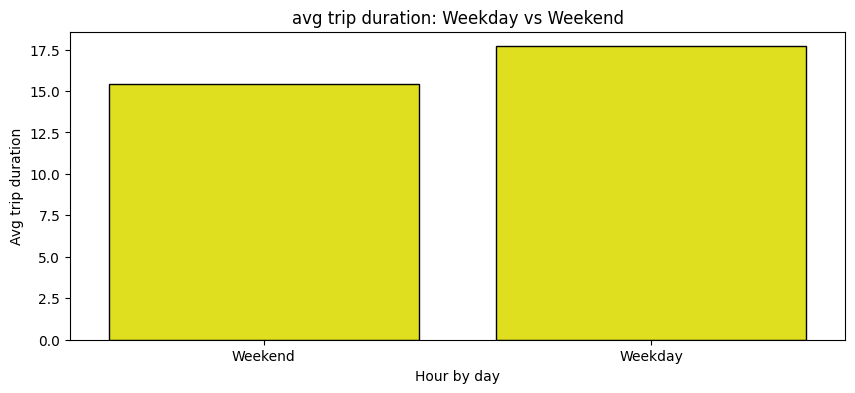

In [18]:
plt.figure(figsize=(10,4))
sns.barplot(x="day_type",y="avg_duration",data=weekend_df,color="yellow",edgecolor="black")
plt.title("avg trip duration: Weekday vs Weekend")
plt.xlabel("Hour by day")
plt.ylabel("Avg trip duration")
plt.show()

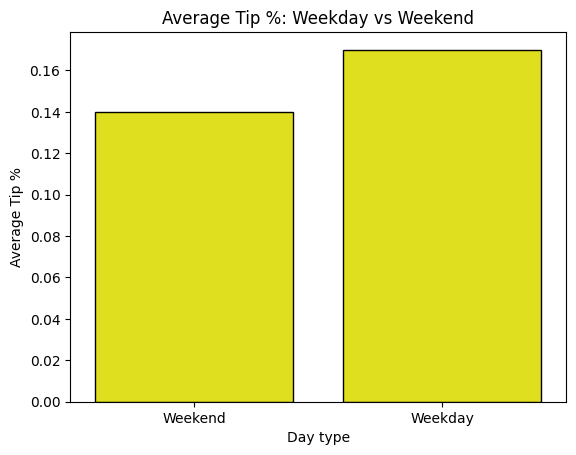

In [19]:
plt.Figure(figsize=(6,4))
sns.barplot(x="day_type", y="avg_tip_percentage", data=weekend_df, color="yellow", edgecolor="black")
plt.xlabel("Day type")
plt.ylabel("Average Tip %")
plt.title("Average Tip %: Weekday vs Weekend")
plt.show()

In [20]:

# Zone-level revenue intelligence

In [21]:
zones=pd.read_csv(r"C:\Users\baavi\Downloads\taxi_zone_lookup.csv")
zones.head()

,LocationID,Borough,Zone,service_zone
0,1,EWR,Newark Airport,EWR
1,2,Queens,Jamaica Bay,Boro Zone
2,3,Bronx,Allerton/Pelham Gardens,Boro Zone
3,4,Manhattan,Alphabet City,Yellow Zone
4,5,Staten Island,Arden Heights,Boro Zone


In [22]:
zones.tail()

,LocationID,Borough,Zone,service_zone
260,261,Manhattan,World Trade Center,Yellow Zone
261,262,Manhattan,Yorkville East,Yellow Zone
262,263,Manhattan,Yorkville West,Yellow Zone
263,264,Unknown,NaN,NaN
264,265,NaN,Outside of NYC,NaN


In [23]:
zones.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 265 entries, 0 to 264
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   LocationID    265 non-null    int64 
 1   Borough       264 non-null    object
 2   Zone          264 non-null    object
 3   service_zone  263 non-null    object
dtypes: int64(1), object(3)
memory usage: 8.4+ KB


In [24]:
zones.describe()

,LocationID
count,265.000000
mean,133.000000
std,76.643112
min,1.000000
25%,67.000000
50%,133.000000
75%,199.000000
max,265.000000


In [25]:
zones.isnull().sum()

LocationID      0
Borough         1
Zone            1
service_zone    2
dtype: int64

In [26]:
Borough_mode=zones['Borough'].mode()[0]

In [27]:
Borough_mode

'Manhattan'

In [28]:
zones['Borough']=zones['Borough'].fillna(Borough_mode)

In [29]:
Zone_mode=zones['Zone'].mode()[0]
Zone_mode

"Governor's Island/Ellis Island/Liberty Island"

In [30]:
zones['Zone']=zones['Zone'].fillna(Zone_mode)

In [31]:
zones.isnull().sum()

LocationID      0
Borough         0
Zone            0
service_zone    2
dtype: int64

In [32]:
service_zone_mode=zones['service_zone'].mode()[0]
service_zone_mode

'Boro Zone'

In [33]:
zones['service_zone']=zones['service_zone'].fillna(service_zone_mode)

In [34]:
zones.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 265 entries, 0 to 264
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   LocationID    265 non-null    int64 
 1   Borough       265 non-null    object
 2   Zone          265 non-null    object
 3   service_zone  265 non-null    object
dtypes: int64(1), object(3)
memory usage: 8.4+ KB


In [35]:
connection.register('zones',zones)

In [36]:
query = """
select 
  z.Borough,
  z.Zone,
  count(*) as total_trips,
  sum(t.total_amount) as total_revenue,
  round(avg(t.total_amount), 2) as avg_revenue_per_trip
from taxi t 
join zones z
on t.PULocationID = z.LocationID
group by z.Borough,z.zone
order by total_revenue desc
limit 10
"""
top_zones=connection.execute(query).df()
top_zones

,Borough,Zone,total_trips,total_revenue,avg_revenue_per_trip
0,Queens,JFK Airport,45948,3287324.04,71.54
1,Queens,LaGuardia Airport,31818,2155587.40,67.75
2,Manhattan,Midtown Center,54729,1419038.04,25.93
3,Manhattan,Upper East Side North,57475,1285681.59,22.37
4,Manhattan,Upper East Side South,59950,1283906.89,21.42
5,Manhattan,Times Sq/Theatre District,39189,1092723.70,27.88
6,Manhattan,Penn Station/Madison Sq West,41753,1055837.14,25.29
7,Manhattan,Midtown East,40746,1027521.63,25.22
8,Manhattan,East Village,38073,956050.96,25.11
9,Manhattan,Lincoln Square East,41207,944511.55,22.92


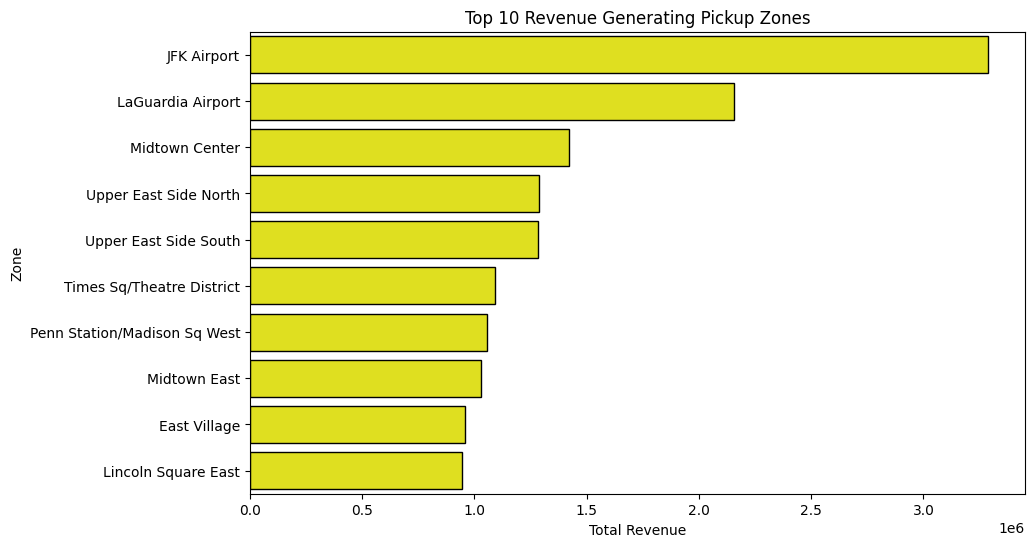

In [37]:
plt.figure(figsize=(10,6))
sns.barplot(data=top_zones, y="Zone", x="total_revenue", color="yellow", edgecolor="black")
plt.title("Top 10 Revenue Generating Pickup Zones")
plt.xlabel("Total Revenue")
plt.ylabel("Zone")
plt.show()

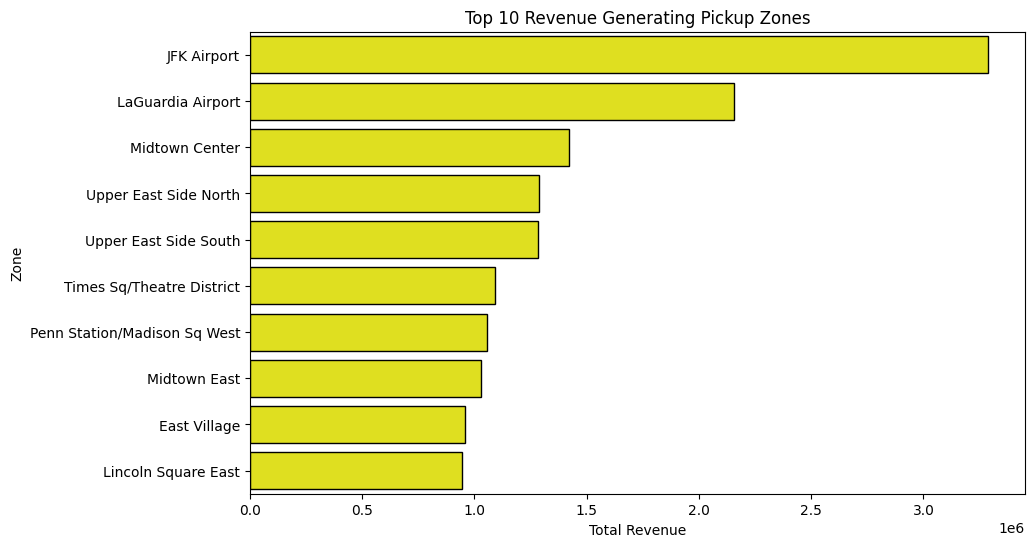

In [38]:
plt.figure(figsize=(10,6))
sns.barplot(data=top_zones, y="Zone", x="total_revenue", color="yellow", edgecolor="black")
plt.title("Top 10 Revenue Generating Pickup Zones")
plt.xlabel("Total Revenue")
plt.ylabel("Zone")
plt.show()

In [39]:
#JFK Airport generates the highest revenue
#Most top zones are in manhattan
#Airports are dominating among other zones 

In [40]:
#Borough-level analysis
query = """
select 
  z.Borough,
  count(*) as total_trips,
  sum(t.total_amount) as total_revenue,
  round(avg(t.total_amount), 2) as avg_revenue_per_trip
from taxi t 
join zones z
on t.PULocationID = z.LocationID
group by z.Borough
order by total_revenue desc
"""

borough=connection.execute(query).df()
borough


,Borough,total_trips,total_revenue,avg_revenue_per_trip
0,Manhattan,1182579,2.969112e+07,25.11
1,Queens,113808,6.751841e+06,59.33
2,Brooklyn,55853,1.888004e+06,33.80
3,Bronx,13386,4.643675e+05,34.69
4,Unknown,1528,4.378954e+04,28.66
5,Staten Island,133,5.188460e+03,39.01
6,EWR,1,6.100000e+01,61.00


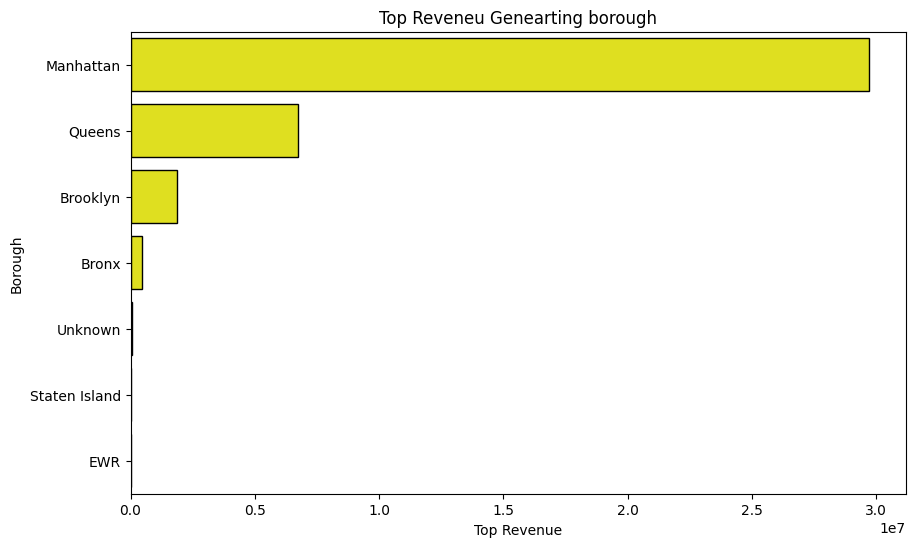

In [41]:
plt.figure(figsize=(10,6))
sns.barplot(data=borough,x="total_revenue",y="Borough",color="yellow",edgecolor="black")
plt.title("Top Reveneu Genearting borough")
plt.xlabel("Top Revenue")
plt.ylabel("Borough")
plt.show()

In [42]:
#Manhattan division generates most revenue out of all divisions
#Queens division has the highest average revenue per trip
#EWR division generates the lowest revenue out of all divisions

In [43]:
#HOURLY DEMAND PERCENTILE

In [44]:
hourly_df["demand_percentile"] = round(hourly_df["total_trips"].rank(pct=True) * 100, 2)
hourly_df

,pickup_hour,total_trips,total_revenue,avg_fare,avg_tip,avg_trip_duration,Revenue_per_trip,demand_percentile
0,0,42650,1246960.81,21.18,2.05,14.89,29.237065,29.17
1,1,29388,831764.89,20.76,1.73,14.08,28.302875,25.00
2,2,20706,561816.60,19.82,1.60,13.77,27.133034,16.67
3,3,14766,403628.56,20.28,1.45,14.07,27.334997,12.50
4,4,10656,321120.56,22.94,1.53,15.56,30.135188,4.17
5,5,12266,395065.88,24.90,1.72,19.03,32.208208,8.33
6,6,23677,729107.53,23.94,1.61,20.65,30.793915,20.83
7,7,42821,1264187.76,22.46,1.90,19.31,29.522612,33.33
8,8,55974,1602227.76,21.37,2.13,18.38,28.624500,37.50
9,9,59185,1619782.16,19.90,2.36,17.80,27.368120,45.83


In [45]:
hourly_df.tail()

,pickup_hour,total_trips,total_revenue,avg_fare,avg_tip,avg_trip_duration,Revenue_per_trip,demand_percentile
19,19,79908,2280880.45,18.91,2.87,15.74,28.543831,79.17
20,20,81035,2312638.45,19.80,2.61,15.49,28.538760,83.33
21,21,81221,2335338.18,20.08,2.58,15.10,28.752886,87.50
22,22,74142,2159747.37,20.62,2.45,15.38,29.129877,66.67
23,23,57926,1717339.57,21.29,2.26,15.29,29.647129,41.67


In [46]:
hourly_df.isnull().sum()

pickup_hour          0
total_trips          0
total_revenue        0
avg_fare             0
avg_tip              0
avg_trip_duration    0
Revenue_per_trip     0
demand_percentile    0
dtype: int64

In [47]:
def surge_multiplier(p):
    if p < 75:
        return 1.0
    elif p < 85:
        return 1.2
    elif p < 95:
        return 1.5
    else:
        return 2.0

hourly_df["surge_multiplier"] = hourly_df["demand_percentile"].apply(surge_multiplier)

hourly_df

,pickup_hour,total_trips,total_revenue,avg_fare,avg_tip,avg_trip_duration,Revenue_per_trip,demand_percentile,surge_multiplier
0,0,42650,1246960.81,21.18,2.05,14.89,29.237065,29.17,1.0
1,1,29388,831764.89,20.76,1.73,14.08,28.302875,25.00,1.0
2,2,20706,561816.60,19.82,1.60,13.77,27.133034,16.67,1.0
3,3,14766,403628.56,20.28,1.45,14.07,27.334997,12.50,1.0
4,4,10656,321120.56,22.94,1.53,15.56,30.135188,4.17,1.0
5,5,12266,395065.88,24.90,1.72,19.03,32.208208,8.33,1.0
6,6,23677,729107.53,23.94,1.61,20.65,30.793915,20.83,1.0
7,7,42821,1264187.76,22.46,1.90,19.31,29.522612,33.33,1.0
8,8,55974,1602227.76,21.37,2.13,18.38,28.624500,37.50,1.0
9,9,59185,1619782.16,19.90,2.36,17.80,27.368120,45.83,1.0


In [48]:
hourly_df["surge_revenue"] = hourly_df["total_revenue"] *hourly_df["surge_multiplier"]
hourly_df

,pickup_hour,total_trips,total_revenue,avg_fare,avg_tip,avg_trip_duration,Revenue_per_trip,demand_percentile,surge_multiplier,surge_revenue
0,0,42650,1246960.81,21.18,2.05,14.89,29.237065,29.17,1.0,1246960.810
1,1,29388,831764.89,20.76,1.73,14.08,28.302875,25.00,1.0,831764.890
2,2,20706,561816.60,19.82,1.60,13.77,27.133034,16.67,1.0,561816.600
3,3,14766,403628.56,20.28,1.45,14.07,27.334997,12.50,1.0,403628.560
4,4,10656,321120.56,22.94,1.53,15.56,30.135188,4.17,1.0,321120.560
5,5,12266,395065.88,24.90,1.72,19.03,32.208208,8.33,1.0,395065.880
6,6,23677,729107.53,23.94,1.61,20.65,30.793915,20.83,1.0,729107.530
7,7,42821,1264187.76,22.46,1.90,19.31,29.522612,33.33,1.0,1264187.760
8,8,55974,1602227.76,21.37,2.13,18.38,28.624500,37.50,1.0,1602227.760
9,9,59185,1619782.16,19.90,2.36,17.80,27.368120,45.83,1.0,1619782.160


In [49]:
original_revenue = hourly_df["total_revenue"].sum()
surge_revenue = hourly_df["surge_revenue"].sum()

increase_percentage = round(((surge_revenue - original_revenue) / original_revenue) *100, 2).astype(str) + " %"
print("revenue before surge :", original_revenue)
print()
print("revenue after surge :", surge_revenue)
print()
print("percentage change :", increase_percentage)

revenue before surge : 38844375.269999996

revenue after surge : 47463786.646

percentage change : 22.19 %


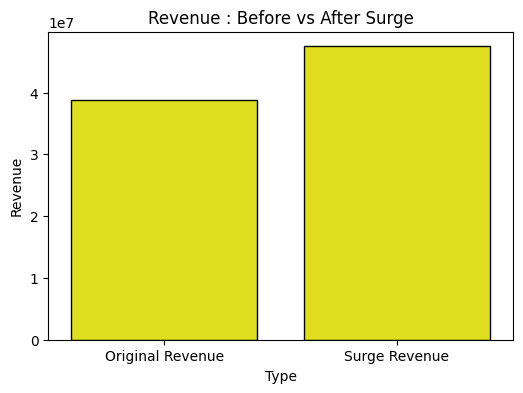

In [50]:
surge_df = pd.DataFrame({
    "Type": ["Original Revenue", "Surge Revenue"],
    "Revenue": [original_revenue, surge_revenue]
})

plt.figure(figsize=(6,4))
sns.barplot(data = surge_df, x = "Type", y = "Revenue", color = "yellow", edgecolor="black")
plt.title("Revenue : Before vs After Surge")
plt.show()

In [51]:
final_df = df.copy()

# Merging surge multiplier by hour
final_df = final_df.merge(
    hourly_df[["pickup_hour", "surge_multiplier"]],
    on="pickup_hour",
    how="left"
)

# Calculating simulated surge fare
final_df["simulated_total_amount"] = (
    final_df["total_amount"] *
    final_df["surge_multiplier"]
)

final_df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,PULocationID,DOLocationID,payment_type,fare_amount,extra,...,trip_duration_min,pickup_hour,pickup_day,pickup_weekday,is_weekend,revenue_per_mile,revenue_per_minute,tip_percentage,surge_multiplier,simulated_total_amount
0,1,2026-01-18 12:35:13,2026-01-18 12:46:05,1.0,3.90,68,238,1,17.00,3.25,...,10.87,12,18,6,1,6.22,2.23,0.15,1.0,24.25
1,2,2026-01-28 01:01:57,2026-01-28 01:34:45,1.0,13.95,69,61,0,49.13,0.00,...,32.80,1,28,2,0,4.16,1.77,0.00,1.0,58.09
2,2,2026-01-09 10:35:27,2026-01-09 11:05:50,1.0,13.79,13,138,1,55.50,5.00,...,30.38,10,9,4,0,6.15,2.79,0.35,1.0,84.82
3,2,2026-01-24 22:26:51,2026-01-24 22:37:03,1.0,1.76,164,79,2,11.40,1.00,...,10.20,22,24,5,1,9.74,1.68,0.00,1.0,17.15
4,2,2026-01-01 01:59:23,2026-01-01 02:13:41,1.0,7.42,74,232,0,41.06,0.00,...,14.30,1,1,3,0,6.17,3.20,0.00,1.0,45.81


In [52]:
final_df.to_csv("final_yellow_tripdata_2025-01.csv", index=False)